# TensorAtlas tutorial: symbolic tensor workflows

This notebook is the main public tutorial for TensorAtlas. It combines the earlier focused workflow notebooks into one executable, sectioned tour. The emphasis is on theory, conventions, complete workflows, and practical examples rather than isolated API calls.

TensorAtlas is built around five complementary ideas:

1. **Coordinate/component computation** for scalar, vector, covector, tensor, and density fields.
2. **Differential forms** for coordinate-light exterior calculus.
3. **Tensor-valued forms** for Cartan calculus, gauge curvature, solder forms, torsion, and curvature 2-forms.
4. **Metric geometry and relativity workflows** for Christoffel symbols, curvature tensors, Einstein tensors, and geodesics.
5. **Canonical symbolic tensor expressions** for comparing tensor expressions using structural normal forms.


## 1. Setup and tutorial conventions

Most examples use exact symbolic expressions. Expensive simplification is applied selectively; in larger workflows you can often request individual tensor components rather than dense tensors. Curvature conventions are described in `docs/conventions.md` and in the relevant docstrings.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
SRC = ROOT / "src"

if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

In [2]:
import sympy as sp
from pprint import pprint

from tensoratlas.core import (
    catalog_transition_map,
    coordinate_curl,
    coordinate_divergence,
    coordinate_gradient,
    coordinate_laplacian,
    list_standard_coordinates,
    standard_coordinate_system_data,
    tensor_contract,
    tensor_product,
    transform_covector_field,
    transform_scalar_field,
    transform_tensor_density,
    transform_tensor_field,
    transform_vector_field,
)
from tensoratlas.examples import (
    canonicalization_workflow,
    cartan_structure_workflow,
    coordinate_calculus_workflow,
    differential_forms_workflow,
    electromagnetic_workflow,
    flrw_workflow,
    geometric_algebra_workflow,
    schwarzschild_workflow,
    two_sphere_workflow,
)
from tensoratlas.geometric_algebra import GeometricAlgebra, reflect, rotate, rotor
from tensoratlas.relativity import (
    christoffel_component,
    christoffel_symbols,
    einstein_component,
    flrw_metric,
    geodesic_equations,
    nonzero_components,
    ricci_component,
    riemann_component,
    scalar_curvature,
    schwarzschild_metric,
    two_sphere_metric,
)
from tensoratlas.tensor_valued_forms import (
    TensorValuedForm,
    cartan_first_equation,
    cartan_second_equation,
    connection_form,
    exterior_derivative_tvform,
    gauge_curvature,
    solder_form,
)


## 2. Tensor theory from vectors and covectors

This chapter makes the tutorial more than a feature tour. It builds the conceptual path from vectors and covectors to tensors as multilinear maps and then connects that theory to TensorAtlas operations. The key theme is that an array stores components, while a tensor is the geometric or multilinear object whose components change in a controlled way when the basis or coordinates change.

In [3]:
from tensoratlas.examples.tensor_theory import (
    notation_table,
    vector_covector_pairing_example,
    covariant_contravariant_scaling_example,
    dual_basis_example,
    basis_change_example,
    multilinear_metric_example,
    metric_raising_lowering_example,
    metric_pullback_example,
    tensor_product_contraction_example,
    tensor_theory_workflow,
)
from tensoratlas.examples.physical_tensors import (
    quadrupole_moment_disk_example,
    stress_strain_stiffness_example,
    physical_tensor_workflow,
)


### 2.1 Tensor types in several notations

A tensor type $(r,s)$ has $r$ contravariant slots and $s$ covariant slots. In index notation, contravariant slots are written upstairs and covariant slots downstairs. This is not exponent notation; the position of the index records how the component transforms and what kind of input/output slot it represents.

In [4]:
notation_table()

[{'type': '(1, 0)', 'index': 'v^i', 'meaning': 'vector / tangent vector'},
 {'type': '(0, 1)', 'index': 'alpha_i', 'meaning': 'covector / one-form'},
 {'type': '(1, 1)', 'index': 'A^i_j', 'meaning': 'linear map'},
 {'type': '(0, 2)', 'index': 'g_ij', 'meaning': 'bilinear form / metric'},
 {'type': '(2, 0)',
  'index': 'P^ij',
  'meaning': 'contravariant rank-two tensor'},
 {'type': '(2, 2)',
  'index': 'R^ij_kl',
  'meaning': 'mixed tensor such as a curvature-like object'}]

### 2.2 Vectors, covectors, and pairings

A vector is naturally represented by components in a basis. A covector is a linear functional: it takes a vector and returns a scalar. This pairing is the simplest example of a tensorial operation because the scalar result is independent of the chosen basis.

In [5]:
pairing = vector_covector_pairing_example()
pairing

{'vector': Matrix([
 [ 2],
 [-1]]),
 'covector': Matrix([[3, 5]]),
 'pairing': 1}

### 2.3 Covariant and contravariant scaling

Contravariant components scale opposite to the basis: the same 1 km length has larger numerical components when measured in meters or millimeters. Covariant quantities such as rates per unit distance scale with the basis: calories per meter is numerically smaller than calories per kilometer.

In [6]:
covariant_contravariant_scaling_example()

{'length_components': (1, 1000, 1000000),
 'rate_components': (60, 3/50, 3/50000)}

### 2.4 Dual bases and the Kronecker delta

Given a basis matrix whose columns are basis vectors, the dual basis consists of rows that evaluate to one on the matching basis vector and zero on the others:

$$\epsilon^i(e_j)=\delta^i{}_j.$$

This is the concrete linear-algebra version of the relationship between a vector basis and a covector basis.

In [7]:
dual = dual_basis_example()
dual["basis_matrix"], dual["dual_basis_rows"], dual["kronecker_delta"]

(Matrix([
 [1, 1],
 [0, 2]]),
 Matrix([
 [1, -1/2],
 [0,  1/2]]),
 Matrix([
 [1, 0],
 [0, 1]]))

### 2.5 Basis changes: vectors, covectors, and linear maps

The same geometric object has different components in different bases. Vector components transform with the inverse basis matrix, covectors transform with the dual rule, and a linear map has one contravariant and one covariant slot. The example below verifies both a covector-vector pairing and a linear-map action after a non-orthogonal basis change.

In [8]:
basis_change = basis_change_example()
basis_change["pairing_difference"], basis_change["linear_map_consistency"], basis_change["linear_map_new"]

(0,
 Matrix([
 [0],
 [0]]),
 Matrix([
 [-1/2, -1/2],
 [ 3/2, 11/2]]))

### 2.6 Tensors as multilinear maps

A covector is linear in one vector input. A metric tensor is bilinear: it accepts two vectors and returns a scalar, linearly in each argument. This example verifies linearity in the first slot symbolically.

In [9]:
metric_example = multilinear_metric_example()
metric_example["metric"], metric_example["value"], metric_example["linearity_residual"]

(Matrix([
 [1, 0],
 [0, 4]]),
 x1*y1 + 4*x2*y2,
 0)

### 2.7 The metric as a vector-to-covector map

A metric is often displayed as a matrix, but conceptually it is a $(0,2)$ tensor. Feeding one vector into the metric lowers an index and produces a covector:

$$v^\flat_i = g_{ij} v^j.$$

The inverse metric raises the index again.

In [10]:
raising = metric_raising_lowering_example()
raising["metric"], raising["lowered"], raising["raise_lower_residual"]

(Matrix([
 [1,    0],
 [0, r**2]]),
 Matrix([
 [         v_r],
 [r**2*v_theta]]),
 Matrix([
 [0],
 [0]]))

### 2.8 Deriving a curvilinear metric by pullback

The polar metric can be derived from the Euclidean Cartesian metric with a Jacobian pullback:

$$g_{ab}^{\mathrm{polar}} = \frac{\partial x^i}{\partial q^a}\frac{\partial x^j}{\partial q^b} g_{ij}^{\mathrm{cart}}.$$

This is a concrete example of the covariant rank-two tensor transformation rule.

In [11]:
pullback = metric_pullback_example()
pullback["jacobian"], pullback["polar_metric"]

(Matrix([
 [cos(theta), -rho*sin(theta)],
 [sin(theta),  rho*cos(theta)]]),
 Matrix([
 [1,      0],
 [0, rho**2]]))

### 2.9 Tensor products, elementary tensors, and contractions

An elementary tensor is built as a tensor product of vectors and covectors. More general tensors are sums of such elementary tensors. A contraction pairs one contravariant-like axis with one covariant-like axis, reducing rank. For a matrix, contraction over the two axes gives the trace.

In [12]:
tensor_product_contraction_example()

{'elementary_tensor': ((3, 4), (6, 8)),
 'trace': 5,
 'contracted_product': ((7, 10), (15, 22))}

### 2.10 General tensor transformation rule

For a tensor of type $(r,s)$, each contravariant index receives one factor of the new coordinates with respect to the old coordinates, and each covariant index receives one inverse/dual factor:

$$
\tilde T^{a_1\cdots a_r}{}_{b_1\cdots b_s}
=
\frac{\partial \tilde x^{a_1}}{\partial x^{i_1}}
\cdots
\frac{\partial \tilde x^{a_r}}{\partial x^{i_r}}
\frac{\partial x^{j_1}}{\partial \tilde x^{b_1}}
\cdots
\frac{\partial x^{j_s}}{\partial \tilde x^{b_s}}
T^{i_1\cdots i_r}{}_{j_1\cdots j_s}.
$$

This rule is the organizing principle behind coordinate-field transformations, metrics, curvature tensors, and the component examples below.

## 3. Physical tensor applications

The following examples connect abstract tensor notation to physical tensors. They are intentionally small but show how tensor order and variance encode what the tensor does.

### 3.1 Quadrupole moment tensor

A quadrupole moment is a rank-two tensor built from a charge distribution and position components. For a planar disk with density proportional to $x^2-y^2$, the symbolic integral below produces a traceless Cartesian quadrupole tensor.

In [13]:
quadrupole = quadrupole_moment_disk_example()
quadrupole["density"], quadrupole["quadrupole_tensor"], quadrupole["trace"]

(rho0*(-r**2*sin(theta)**2 + r**2*cos(theta)**2),
 Matrix([
 [pi*R**6*rho0/4,               0, 0],
 [             0, -pi*R**6*rho0/4, 0],
 [             0,               0, 0]]),
 0)

### 3.2 Stress, strain, stiffness, and compliance

In linear elasticity, strain $\epsilon_{ij}$ and stress $\sigma_{ij}$ are rank-two tensors. The stiffness tensor has four indices because it maps a rank-two strain tensor to a rank-two stress tensor:

$$\sigma_{ij}=C_{ijkl}\epsilon_{kl}.$$

The isotropic two-dimensional example below reconstructs Hooke's law using a fourth-order stiffness tensor.

In [14]:
elasticity = stress_strain_stiffness_example()
elasticity["strain"], elasticity["stress"], elasticity["reconstruction_residual"]

(Matrix([
 [epsilon_11, epsilon_12],
 [epsilon_12, epsilon_22]]),
 Matrix([
 [2*epsilon_11*mu + lambda*(epsilon_11 + epsilon_22),                                    2*epsilon_12*mu],
 [                                   2*epsilon_12*mu, 2*epsilon_22*mu + lambda*(epsilon_11 + epsilon_22)]]),
 Matrix([
 [0, 0],
 [0, 0]]))

### 3.3 Complete theory/application workflow dictionary

The example modules are tested outside the notebook, so the tutorial code remains synchronized with the package.

In [15]:
theory_workflow = tensor_theory_workflow()
physical_workflow = physical_tensor_workflow()
theory_workflow.keys(), physical_workflow.keys()

(dict_keys(['notation', 'pairing', 'scaling', 'dual_basis', 'basis_change', 'metric_bilinearity', 'raising_lowering', 'metric_pullback', 'tensor_products']),
 dict_keys(['quadrupole', 'elasticity']))

## 4. TensorAtlas objects: components, variance, and coordinate bases

A tensor field can be represented by components only after a basis has been chosen. TensorAtlas keeps this distinction visible: transformations require a coordinate map, a variance convention, and a component array. Contravariant slots transform with the Jacobian $\partial y^a / \partial x^i$; covariant slots transform with the inverse Jacobian $\partial x^i / \partial y^a$.

A metric lets us lower and raise indices, measure lengths, construct volume forms, define Hodge stars, and build Levi-Civita connections. In curvilinear coordinates, basis vectors are not generally unit length, so coordinate formulas for gradient, divergence, curl, and Laplacian include metric factors.


In [16]:
# The catalog provides named coordinate systems with symbols, metrics, domains, and maps.
coords = list_standard_coordinates()
coords[:8], len(coords)


(('bipolar',
  'bispherical',
  'cartesian2',
  'cartesian3',
  'cartesian4',
  'cylindrical',
  'de_sitter_flat',
  'eddington_finkelstein_ingoing'),
 23)

## 5. Coordinate systems and field transformations

This section demonstrates scalar, vector, covector, rank-2 tensor, and tensor-density transformations between charts. The examples use Cartesian and polar coordinates in two dimensions because their Jacobians are easy to inspect.


In [17]:
polar_data = standard_coordinate_system_data("polar")
polar_data["coordinates"], polar_data["metric"]


((r, theta),
 Matrix([
 [1,    0],
 [0, r**2]]))

In [18]:
cart_to_polar = catalog_transition_map("cartesian2", "polar")
cart_to_polar.source.coordinate_names, cart_to_polar.target.coordinate_names, cart_to_polar.mapping, cart_to_polar.inverse


(('x', 'y'),
 ('r', 'theta'),
 (sqrt(x**2 + y**2), atan2(y, x)),
 (r*cos(theta), r*sin(theta)))

In [19]:
x, y = cart_to_polar.source_symbols
scalar_cart = x**2 + y**2
scalar_polar = transform_scalar_field(scalar_cart, cart_to_polar)
sp.simplify(scalar_polar)


r**2

In [20]:
# Contravariant vector transformation: radial Cartesian vector field (x, y).
vector_polar = transform_vector_field((x, y), cart_to_polar)
vector_polar.components, vector_polar.convention_metadata


((r**2*sin(theta)**2/sqrt(r**2*sin(theta)**2 + r**2*cos(theta)**2) + r**2*cos(theta)**2/sqrt(r**2*sin(theta)**2 + r**2*cos(theta)**2),
  0),
 {'component_basis': 'coordinate',
  'density_convention': 'target components use |det(d source / d target)|^weight',
  'variance_convention': 'contravariant dy/dx; covariant dx/dy',
  'source_chart': 'cartesian2',
  'target_chart': 'polar'})

In [21]:
# Covector transformation: df for f = x^2 + y^2 has Cartesian components (2x, 2y).
covector_polar = transform_covector_field((2*x, 2*y), cart_to_polar)
covector_polar.components


(2*r, 0)

In [22]:
# A rank-2 contravariant tensor and a scalar density illustrate the general machinery.
rank2_cart = ((x, 0), (0, y))
rank2_polar = transform_tensor_field(rank2_cart, cart_to_polar, ("up", "up"))
density_polar = transform_tensor_density(((1, 0), (0, 1)), cart_to_polar, ("down", "down"), weight=1)
rank2_polar.components, density_polar.metadata


(((r*sin(theta)**3 + r*cos(theta)**3,
   r**3*sin(theta)**2*cos(theta)/(r**2*sin(theta)**2 + r**2*cos(theta)**2)**(3/2) - r**3*sin(theta)*cos(theta)**2/(r**2*sin(theta)**2 + r**2*cos(theta)**2)**(3/2)),
  (r**3*sin(theta)**2*cos(theta)/(r**2*sin(theta)**2 + r**2*cos(theta)**2)**(3/2) - r**3*sin(theta)*cos(theta)**2/(r**2*sin(theta)**2 + r**2*cos(theta)**2)**(3/2),
   r**3*sin(theta)**2*cos(theta)/(r**2*sin(theta)**2 + r**2*cos(theta)**2)**2 + r**3*sin(theta)*cos(theta)**2/(r**2*sin(theta)**2 + r**2*cos(theta)**2)**2)),
 {'coordinate_map': 'cartesian2_to_polar',
  'jacobian_det': 1/sqrt(x**2 + y**2),
  'density_jacobian': Abs(r*sin(theta)**2 + r*cos(theta)**2),
  'source_nonzero_components': 2})

## 4. Vector calculus as tensor calculus

The familiar operators $\nabla f$, $\nabla\cdot X$, $\nabla\times X$, and $\Delta f$ are metric-dependent operations. In TensorAtlas, you can compute them directly in curvilinear coordinates by passing the coordinate metric.


In [23]:
coord_result = coordinate_calculus_workflow()
coord_result


{'coordinates': (r, theta),
 'metric': Matrix([
 [1,    0],
 [0, r**2]]),
 'scalar': r**2*sin(theta),
 'gradient': (2*r*sin(theta), r**2*cos(theta)/r**2),
 'divergence': cos(theta) + 1,
 'laplacian': (2*r**2 - r**2)*sin(theta)/r**2}

In [24]:
r, theta = sp.symbols("r theta", positive=True)
polar_metric = standard_coordinate_system_data("polar")["metric"]
f = r**3 * sp.cos(theta)
X = (r, sp.sin(theta))
{
    "gradient": coordinate_gradient(f, (r, theta), metric=polar_metric),
    "divergence": sp.simplify(coordinate_divergence(X, (r, theta), metric=polar_metric)),
    "laplacian": sp.simplify(coordinate_laplacian(f, (r, theta), metric=polar_metric)),
}


{'gradient': (3*r**2*cos(theta), -r**3*sin(theta)/r**2),
 'divergence': cos(theta) + 1,
 'laplacian': r*(6*r**2 - r**2)*cos(theta)/r**2}

In [25]:
# Three-dimensional cylindrical curl example.
rho, phi, z = sp.symbols("rho phi z", positive=True)
cyl_metric = standard_coordinate_system_data("cylindrical")["metric"]
field = (0, rho**2, 0)
coordinate_curl(field, (rho, phi, z), metric=cyl_metric)


(0, 0, 2*rho*rho**2/Abs(rho))

## 5. Tensor arrays: products, contractions, and component workflows

Component arrays are useful when you want explicit entries. Tensor products and contractions are the component-level counterparts of abstract indexed notation.


In [26]:
A = ((1, 2), (3, 4))
B = ((0, 5), (6, 7))
product = tensor_product(A, B)
contracted = tensor_contract(product, (1, 2))
contracted


TensorArray(components=((12, 19), (24, 43)), variance=(None, None), properties={'operation': 'tensor_product', 'factors': 2, 'last_contract': ((1, 2),)})

## 6. Differential forms

Differential forms package antisymmetry into the object itself. They are ideal for integration, fluxes, exterior derivatives, and orientation-sensitive expressions. In physics, they give compact formulations of electromagnetism, vorticity, symplectic geometry, and conservation laws.


In [27]:
forms = differential_forms_workflow()
forms


{'dx': TensorExpr(kind='form:basis', payload='dx', children=(), metadata={'degree': 1, 'frame': None, 'basis_labels': ('dx',)}, provenance=IRProvenance(origin='coframe', steps=(), metadata={})),
 'dy': TensorExpr(kind='form:basis', payload='dy', children=(), metadata={'degree': 1, 'frame': None, 'basis_labels': ('dy',)}, provenance=IRProvenance(origin='coframe', steps=(), metadata={})),
 'area_form': TensorExpr(kind='form:wedge', payload=None, children=(TensorExpr(kind='form:basis', payload='dx', children=(), metadata={'degree': 1, 'frame': None, 'basis_labels': ('dx',)}, provenance=IRProvenance(origin='coframe', steps=(), metadata={})), TensorExpr(kind='form:basis', payload='dy', children=(), metadata={'degree': 1, 'frame': None, 'basis_labels': ('dy',)}, provenance=IRProvenance(origin='coframe', steps=(), metadata={}))), metadata={'degree': 2, 'coefficient': 1, 'basis_labels': ('dx', 'dy')}, provenance=IRProvenance(origin='wedge_canonicalization', steps=(), metadata={}))}

## 7. Electromagnetism with formal forms

In form notation, an electromagnetic potential $A$ is a 1-form and the field strength is $F=dA$. The identity $dF=d^2A=0$ encodes the homogeneous Maxwell equations. Gauge curvature has the schematic form $F=dA + A\wedge A$ for a connection-valued 1-form.


In [28]:
em = electromagnetic_workflow()
em


{'potential': TensorValuedForm(degree=1, variance=(), components={(): A}, label=None, simplify=True),
 'field_strength': TensorValuedForm(degree=2, variance=(), components={(): d(A)}, label='d', simplify=True),
 'bianchi': TensorValuedForm(degree=3, variance=(), components={(): d(d(A))}, label='dd', simplify=True),
 'gauge_curvature': TensorValuedForm(degree=2, variance=(1, -1), components={(0, 0): omega**2 + d(omega)}, label=None, simplify=True)}

In [29]:
potential = TensorValuedForm(1, (), {(): "A"})
field_strength = exterior_derivative_tvform(potential)
bianchi_identity = exterior_derivative_tvform(field_strength)
field_strength, bianchi_identity


(TensorValuedForm(degree=2, variance=(), components={(): d(A)}, label='d', simplify=True),
 TensorValuedForm(degree=3, variance=(), components={(): d(d(A))}, label='dd', simplify=True))

In [30]:
connection = TensorValuedForm(1, (+1, -1), {(0, 0): "A00", (0, 1): "A01", (1, 0): "A10", (1, 1): "A11"})
gauge_curvature(connection)


TensorValuedForm(degree=2, variance=(1, -1), components={(0, 1): A01*(A00 + A11) + d(A01), (0, 0): A00**2 + A01*A10 + d(A00), (1, 1): A01*A10 + A11**2 + d(A11), (1, 0): A10*(A00 + A11) + d(A10)}, label=None, simplify=True)

## 8. Tensor-valued forms and Cartan calculus

Tensor-valued forms combine an exterior-form degree with tensor or bundle indices. The solder form is vector-valued, a connection 1-form is endomorphism-valued, torsion is vector-valued, and curvature is endomorphism-valued.

Cartan's first and second structure equations are represented using the conventions documented in `docs/conventions.md`.


In [31]:
cartan = cartan_structure_workflow()
cartan


{'solder': TensorValuedForm(degree=1, variance=(1,), components={(0,): theta^0, (1,): theta^1}, label='theta', simplify=True),
 'connection': TensorValuedForm(degree=1, variance=(1, -1), components={((0, 1), (0, 1)): omega^(0, 1)_(0, 1), ((0, 1), (1, 0)): omega^(0, 1)_(1, 0), ((1, 0), (0, 1)): omega^(1, 0)_(0, 1), ((1, 0), (1, 0)): omega^(1, 0)_(1, 0)}, label='omega', simplify=True),
 'solder_form': TensorValuedForm(degree=1, variance=(1,), components={(0,): theta^0, (1,): theta^1}, label='theta', simplify=True),
 'connection_form': TensorValuedForm(degree=1, variance=(1, -1), components={((0, 1), (0, 1)): omega^(0, 1)_(0, 1), ((0, 1), (1, 0)): omega^(0, 1)_(1, 0), ((1, 0), (0, 1)): omega^(1, 0)_(0, 1), ((1, 0), (1, 0)): omega^(1, 0)_(1, 0)}, label='omega', simplify=True),
 'torsion': TensorValuedForm(degree=2, variance=(1,), components={(0,): d(theta^0), (1,): d(theta^1)}, label='T', simplify=True),
 'curvature': TensorValuedForm(degree=2, variance=(1, -1), components={((1, 0), (0, 1)

In [32]:
theta_form = solder_form({0: "theta0", 1: "theta1"})
omega_form = connection_form({(0, 1): "omega01", (1, 0): "omega10"})
torsion = cartan_first_equation(theta_form, omega_form)
curvature = cartan_second_equation(omega_form)
{
    "theta_degree_variance": (theta_form.degree, theta_form.variance),
    "omega_degree_variance": (omega_form.degree, omega_form.variance),
    "torsion": torsion,
    "curvature": curvature,
}


{'theta_degree_variance': (1, (1,)),
 'omega_degree_variance': (1, (1, -1)),
 'torsion': TensorValuedForm(degree=2, variance=(1,), components={(0,): d(theta^0), (1,): d(theta^1)}, label='T', simplify=True),
 'curvature': TensorValuedForm(degree=2, variance=(1, -1), components={((1, 0), (0, 1)): omega^(1, 0)_(0, 1)*(omega^(0, 1)_(0, 1) + omega^(1, 0)_(1, 0)) + d(omega^(1, 0)_(0, 1)), ((0, 1), (1, 0)): omega^(0, 1)_(1, 0)*(omega^(0, 1)_(0, 1) + omega^(1, 0)_(1, 0)) + d(omega^(0, 1)_(1, 0)), ((1, 0), (1, 0)): omega^(0, 1)_(1, 0)*omega^(1, 0)_(0, 1) + omega^(1, 0)_(1, 0)**2 + d(omega^(1, 0)_(1, 0)), ((0, 1), (0, 1)): omega^(0, 1)_(0, 1)**2 + omega^(0, 1)_(1, 0)*omega^(1, 0)_(0, 1) + d(omega^(0, 1)_(0, 1))}, label=None, simplify=True)}

## 9. Metric geometry: the 2-sphere

The round 2-sphere of radius $R$ is a compact example where the full symbolic curvature computation is small enough to inspect. The scalar curvature is $2/R^2$.


In [33]:
sphere = two_sphere_metric()
sphere.coordinates, sphere.metric


((theta, phi),
 Matrix([
 [R**2,                  0],
 [   0, R**2*sin(theta)**2]]))

In [34]:
sphere_result = two_sphere_workflow()
sphere_result


{'metric': Matrix([
 [R**2,                  0],
 [   0, R**2*sin(theta)**2]]),
 'scalar_curvature': 0,
 'gamma_theta_phiphi': -sin(theta)*cos(theta),
 'riemann_theta_phi_theta_phi': sin(theta)**2,
 'coordinates': (theta, phi)}

In [35]:
R = sphere.parameters[0]
{
    "Gamma^theta_{phi phi}": christoffel_component(sphere, 0, 1, 1),
    "R^theta_{phi theta phi}": riemann_component(sphere, 0, 1, 0, 1),
    "Ricci_theta_theta": ricci_component(sphere, 0, 0),
    "scalar_curvature_minus_expected": sp.simplify(scalar_curvature(sphere) - 2/R**2),
}


{'Gamma^theta_{phi phi}': -sin(theta)*cos(theta),
 'R^theta_{phi theta phi}': sin(theta)**2,
 'Ricci_theta_theta': 1,
 'scalar_curvature_minus_expected': 0}

In [36]:
geodesic_equations(sphere)


(-sin(theta(lambda))*cos(theta(lambda))*Derivative(phi(lambda), lambda)**2 + Derivative(theta(lambda), (lambda, 2)),
 (sin(theta(lambda))*Derivative(phi(lambda), (lambda, 2)) + 2*cos(theta(lambda))*Derivative(phi(lambda), lambda)*Derivative(theta(lambda), lambda))/sin(theta(lambda)))

## 10. Relativity workflow: Schwarzschild vacuum check

The Schwarzschild metric is a useful first general-relativity example because selected Ricci components should vanish outside the source. The tutorial uses selected-component APIs to avoid unnecessary dense tensor work.


In [37]:
schwarzschild = schwarzschild_metric()
schwarzschild.coordinates, schwarzschild.metric


((t, r, theta, phi),
 Matrix([
 [2*M/r - 1,              0,    0,                  0],
 [        0, 1/(-2*M/r + 1),    0,                  0],
 [        0,              0, r**2,                  0],
 [        0,              0,    0, r**2*sin(theta)**2]]))

In [38]:
schwarzschild_result = schwarzschild_workflow()
schwarzschild_result


{'metric': Matrix([
 [2*M/r - 1,              0,    0,                  0],
 [        0, 1/(-2*M/r + 1),    0,                  0],
 [        0,              0, r**2,                  0],
 [        0,              0,    0, r**2*sin(theta)**2]]),
 'ricci_tt': 0,
 'ricci_rr': 0,
 'sample_christoffel': M*(-2*M + r)/r**3}

In [39]:
{
    "Ricci_tt": sp.simplify(ricci_component(schwarzschild, 0, 0)),
    "Ricci_rr": sp.simplify(ricci_component(schwarzschild, 1, 1)),
    "Gamma^r_{tt}": christoffel_component(schwarzschild, 1, 0, 0),
}


{'Ricci_tt': 0, 'Ricci_rr': 0, 'Gamma^r_{tt}': M*(-2*M + r)/r**3}

## 11. Relativity workflow: FLRW cosmology

The FLRW metric is the standard homogeneous and isotropic cosmological model. TensorAtlas exposes metric constructors and selected Einstein-tensor components for symbolic exploration.


In [40]:
flrw = flrw_metric()
flrw.coordinates, flrw.metric


((t, r, theta, phi),
 Matrix([
 [-1,                     0,            0,                          0],
 [ 0, a(t)**2/(-k*r**2 + 1),            0,                          0],
 [ 0,                     0, r**2*a(t)**2,                          0],
 [ 0,                     0,            0, r**2*a(t)**2*sin(theta)**2]]))

In [41]:
flrw_result = flrw_workflow()
flrw_result


{'metric': Matrix([
 [-1,                     0,            0,                          0],
 [ 0, a(t)**2/(-k*r**2 + 1),            0,                          0],
 [ 0,                     0, r**2*a(t)**2,                          0],
 [ 0,                     0,            0, r**2*a(t)**2*sin(theta)**2]]),
 'einstein_tt': 3*(k + Derivative(a(t), t)**2)/a(t)**2,
 'einstein_rr': (k + 2*a(t)*Derivative(a(t), (t, 2)) + Derivative(a(t), t)**2)/(k*r**2 - 1)}

In [42]:
{
    "G_tt": einstein_component(flrw, 0, 0),
    "G_rr": einstein_component(flrw, 1, 1),
}


{'G_tt': 3*(k + Derivative(a(t), t)**2)/a(t)**2,
 'G_rr': (k + 2*a(t)*Derivative(a(t), (t, 2)) + Derivative(a(t), t)**2)/(k*r**2 - 1)}

## 12. Inspecting nonzero components and controlling cost

Dense symbolic curvature tensors can be expensive, so I'd suggest selected-component APIs for exploratory work, and use nonzero-component inspection on small examples.


In [43]:
sphere_gamma = christoffel_symbols(sphere)
nonzero_components(sphere_gamma)


{(0, 1, 1): -sin(theta)*cos(theta),
 (1, 0, 1): cos(theta)/sin(theta),
 (1, 1, 0): cos(theta)/sin(theta)}

## 13. Abstract tensor canonicalization and trust/debugging

Canonicalization helps compare expressions that differ by dummy-index names, product order, or structural representation. A useful workflow is to inspect both the canonical expression and its canonical key.


In [44]:
canon = canonicalization_workflow()
canon


{'expression': TensorExpr(kind='tensor:product', payload=None, children=(), metadata={'children': (TensorExpr(kind='T', payload=('a', 'b'), children=(), metadata={}, provenance=IRProvenance(origin='direct', steps=(), metadata={})), TensorExpr(kind='S', payload=('b',), children=(), metadata={}, provenance=IRProvenance(origin='direct', steps=(), metadata={})))}, provenance=IRProvenance(origin='direct', steps=(), metadata={})),
 'canonical': TensorExpr(kind='tensor:product', payload=None, children=(), metadata={'children': (TensorExpr(kind='T', payload=('a', 'b'), children=(), metadata={}, provenance=IRProvenance(origin='direct', steps=(), metadata={})), TensorExpr(kind='S', payload=('b',), children=(), metadata={}, provenance=IRProvenance(origin='direct', steps=(), metadata={})))}, provenance=IRProvenance(origin='direct', steps=(), metadata={})),
 'canonical_key': ('tensor:product',
  None,
  (('children',
    (TensorExpr(kind='T', payload=('a', 'b'), children=(), metadata={}, provenance

## 14. Geometric algebra with orthogonal metrics

TensorAtlas provides a small native multivector layer for diagonal metric signatures. It supports geometric products, exterior products, grade selection, reverse-like involutions, rotors, reflections, and rotations. Non-diagonal metrics are intentionally rejected rather than simplified incorrectly.


In [45]:
ga_result = geometric_algebra_workflow()
ga_result


{'e1_squared': 1*1,
 'anticommutator': 0,
 'bivector': 1*e1^e2,
 'rotor': cos(alpha/2)*1 + -sin(alpha/2)*e1^e2,
 'rotated_vector': (-2*sin(alpha/2) + cos(alpha/2))*cos(alpha/2) - (sin(alpha/2) + 2*cos(alpha/2))*sin(alpha/2)*e1 + (-2*sin(alpha/2) + cos(alpha/2))*sin(alpha/2) + (sin(alpha/2) + 2*cos(alpha/2))*cos(alpha/2)*e2,
 'reflected_vector': -1*e1 + 2*e2}

In [46]:
ga = GeometricAlgebra.euclidean(2)
e1, e2 = ga.basis_vectors()
I = e1.exterior(e2)
alpha = sp.symbols("alpha")
Rrot = rotor(alpha, I)
vector = e1 + 2*e2
{
    "e1_squared": e1 * e1,
    "e1e2_plus_e2e1": e1*e2 + e2*e1,
    "basis_product_e1e1": ga.basis_product([0, 0]),
    "rotor": Rrot,
    "rotated_vector": rotate(vector, Rrot),
    "reflected_vector": reflect(vector, e1),
}


{'e1_squared': 1*1,
 'e1e2_plus_e2e1': 0,
 'basis_product_e1e1': 1*1,
 'rotor': cos(alpha/2)*1 + -sin(alpha/2)*e1^e2,
 'rotated_vector': (-2*sin(alpha/2) + cos(alpha/2))*cos(alpha/2) - (sin(alpha/2) + 2*cos(alpha/2))*sin(alpha/2)*e1 + (-2*sin(alpha/2) + cos(alpha/2))*sin(alpha/2) + (sin(alpha/2) + 2*cos(alpha/2))*cos(alpha/2)*e2,
 'reflected_vector': -1*e1 + 2*e2}

In [47]:
spacetime = GeometricAlgebra.spacetime()
gamma0, gamma1, gamma2, gamma3 = spacetime.basis_vectors()
{
    "gamma0_squared": gamma0 * gamma0,
    "gamma1_squared": gamma1 * gamma1,
    "gamma0_gamma1_anticommutator": gamma0*gamma1 + gamma1*gamma0,
}


{'gamma0_squared': -1*1,
 'gamma1_squared': 1*1,
 'gamma0_gamma1_anticommutator': 0}

## 15. Notebook-grade geometry examples

The package also includes curated geometry examples used for regression-style tutorial validation. These are useful for checking that semantic workflows produce inspectable outputs.


In [48]:
try:
    from tensoratlas.notebook_examples import all_notebook_examples, run_regression_benchmarks
    notebook_examples = all_notebook_examples()
    [(example.name, example.dimension, sorted(example.known_components.keys())) for example in notebook_examples]
except Exception as exc:
    # Keep the tutorial robust if optional advanced examples are unavailable.
    type(exc).__name__, str(exc)


## 16. Application gallery

The same core operations support many domains:

- **Electromagnetism:** potentials, field strengths, Hodge duals, and gauge curvature.
- **Continuum mechanics:** strain, stress, invariants, and constitutive tensor contractions.
- **Fluid mechanics:** vorticity, flux forms, incompressibility, and coordinate-aware divergence.
- **Surface geometry:** induced metrics, Christoffel symbols, geodesics, curvature invariants.
- **General relativity:** metric catalogs, selected curvature components, Einstein tensor checks.
- **Robotics and graphics:** frame transformations, rotations, bivectors, and multivectors.
- **Symbolic verification:** canonical keys, dummy-index normalization, and tensor identity testing.


The gallery below is intentionally compact: each application states the tensorial object, runs a small example, and returns a result that can be inspected immediately. Earlier chapters explain the underlying theory in more detail; this section answers the practical question, “where does this machinery show up?”


### 16.1 Coordinate-field transformations

**Tensor object:** scalar, vector, covector, rank-2 tensor, and density components under a coordinate change. This example uses the Cartesian-to-polar map and shows that the same geometric quantity has different component formulas in different charts.


In [49]:
# Coordinate-field transformation gallery item
x, y, r, theta = sp.symbols("x y r theta", positive=True)
cart_to_polar = catalog_transition_map("cartesian2", "polar")
scalar_cart = x**2 + y**2
vector_cart = (x, y)
covector_cart = (2*x, 2*y)
metric_cart = ((1, 0), (0, 1))
{
    "map": cart_to_polar.summary(),
    "scalar_in_polar": transform_scalar_field(scalar_cart, cart_to_polar),
    "vector_in_polar": transform_vector_field(vector_cart, cart_to_polar),
    "covector_in_polar": transform_covector_field(covector_cart, cart_to_polar),
    "metric_in_polar": transform_tensor_field(metric_cart, cart_to_polar, variance=("down", "down")),
}


{'map': {'name': 'cartesian2_to_polar',
  'source': 'cartesian2',
  'target': 'polar',
  'source_coordinates': ('x', 'y'),
  'target_coordinates': ('r', 'theta'),
  'mapping': (sqrt(x**2 + y**2), atan2(y, x)),
  'inverse_available': True,
  'singularities': ((r, 'origin r=0'),
   (1/sqrt(x**2 + y**2), 'Jacobian determinant vanishes'))},
 'scalar_in_polar': x**2 + y**2,
 'vector_in_polar': FieldTransformationResult(field_type='vector', source_coordinates=('x', 'y'), target_coordinates=('r', 'theta'), components=((r*x*cos(theta) + r*y*sin(theta))/Abs(r), (-x*sin(theta) + y*cos(theta))/r), variance=('up',), density_weight=0, metadata={'coordinate_map': 'cartesian2_to_polar', 'jacobian_det': 1/sqrt(x**2 + y**2), 'density_jacobian': None, 'source_nonzero_components': 2}, convention_metadata={'component_basis': 'coordinate', 'density_convention': 'target components use |det(d source / d target)|^weight', 'variance_convention': 'contravariant dy/dx; covariant dx/dy', 'source_chart': 'cartesia

### 16.2 Vector calculus and fluids

**Tensor object:** vector fields and scalar fields on a coordinate chart. Divergence, curl, gradient, and Laplacian are coordinate-aware operations that can represent incompressibility, vorticity, flux, and diffusion.


In [50]:
# Fluid/vector-calculus gallery item
x, y = sp.symbols("x y")
solid_rotation = (-y, x)
radial_potential = x**2 + y**2
{
    "curl_of_solid_rotation": coordinate_curl(solid_rotation, (x, y)),
    "divergence_of_solid_rotation": coordinate_divergence(solid_rotation, (x, y)),
    "gradient_of_radial_potential": coordinate_gradient(radial_potential, (x, y)),
    "laplacian_of_radial_potential": coordinate_laplacian(radial_potential, (x, y)),
}


{'curl_of_solid_rotation': (2,),
 'divergence_of_solid_rotation': 0,
 'gradient_of_radial_potential': (2*x, 2*y),
 'laplacian_of_radial_potential': 4}

### 16.3 Differential forms

**Tensor object:** antisymmetric covariant tensors. A wedge product builds oriented area forms, and exterior derivatives encode coordinate-light calculus operations.


In [51]:
# Differential-forms gallery item
from tensoratlas.differential_forms_frame import basis_one_form, wedge_forms

dx = basis_one_form("dx")
dy = basis_one_form("dy")
area_form = wedge_forms(dx, dy)
{
    "dx": dx,
    "dy": dy,
    "dx_wedge_dy": area_form,
    "workflow_area_form": differential_forms_workflow()["area_form"],
}


{'dx': TensorExpr(kind='form:basis', payload='dx', children=(), metadata={'degree': 1, 'frame': None, 'basis_labels': ('dx',)}, provenance=IRProvenance(origin='coframe', steps=(), metadata={})),
 'dy': TensorExpr(kind='form:basis', payload='dy', children=(), metadata={'degree': 1, 'frame': None, 'basis_labels': ('dy',)}, provenance=IRProvenance(origin='coframe', steps=(), metadata={})),
 'dx_wedge_dy': TensorExpr(kind='form:wedge', payload=None, children=(TensorExpr(kind='form:basis', payload='dx', children=(), metadata={'degree': 1, 'frame': None, 'basis_labels': ('dx',)}, provenance=IRProvenance(origin='coframe', steps=(), metadata={})), TensorExpr(kind='form:basis', payload='dy', children=(), metadata={'degree': 1, 'frame': None, 'basis_labels': ('dy',)}, provenance=IRProvenance(origin='coframe', steps=(), metadata={}))), metadata={'degree': 2, 'coefficient': 1, 'basis_labels': ('dx', 'dy')}, provenance=IRProvenance(origin='wedge_canonicalization', steps=(), metadata={})),
 'workflo

### 16.4 Electromagnetism

**Tensor object:** a potential 1-form and field-strength 2-form. In exterior-calculus notation, the electromagnetic field strength is $F=dA$, and the Bianchi identity is the formal statement $dF=d(dA)=0$.


In [52]:
# Electromagnetism gallery item
em = electromagnetic_workflow()
{
    "potential_A": em["potential"].summary(),
    "field_strength_F": em["field_strength"].summary(),
    "bianchi_expression": em["bianchi"].summary(),
    "gauge_curvature": em["gauge_curvature"].summary(),
}


{'potential_A': {'degree': 1,
  'rank': 0,
  'variance': (),
  'label': None,
  'nonzero_components': 1,
  'component_keys': ((),)},
 'field_strength_F': {'degree': 2,
  'rank': 0,
  'variance': (),
  'label': 'd',
  'nonzero_components': 1,
  'component_keys': ((),)},
 'bianchi_expression': {'degree': 3,
  'rank': 0,
  'variance': (),
  'label': 'dd',
  'nonzero_components': 1,
  'component_keys': ((),)},
 'gauge_curvature': {'degree': 2,
  'rank': 2,
  'variance': (1, -1),
  'label': None,
  'nonzero_components': 1,
  'component_keys': ((0, 0),)}}

### 16.5 Tensor-valued forms and Cartan geometry

**Tensor object:** vector-valued and endomorphism-valued differential forms. Cartan’s structure equations express torsion and curvature through the solder form and connection form.


In [53]:
# Cartan/tensor-valued-forms gallery item
cartan = cartan_structure_workflow()
{
    "solder_form": cartan["solder"].summary(),
    "connection_form": cartan["connection"].summary(),
    "torsion": cartan["torsion"].summary(),
    "curvature": cartan["curvature"].summary(),
}


{'solder_form': {'degree': 1,
  'rank': 1,
  'variance': (1,),
  'label': 'theta',
  'nonzero_components': 2,
  'component_keys': ((0,), (1,))},
 'connection_form': {'degree': 1,
  'rank': 2,
  'variance': (1, -1),
  'label': 'omega',
  'nonzero_components': 4,
  'component_keys': (((0, 1), (0, 1)),
   ((0, 1), (1, 0)),
   ((1, 0), (0, 1)),
   ((1, 0), (1, 0)))},
 'torsion': {'degree': 2,
  'rank': 1,
  'variance': (1,),
  'label': 'T',
  'nonzero_components': 2,
  'component_keys': ((0,), (1,))},
 'curvature': {'degree': 2,
  'rank': 2,
  'variance': (1, -1),
  'label': None,
  'nonzero_components': 4,
  'component_keys': (((1, 0), (0, 1)),
   ((0, 1), (1, 0)),
   ((1, 0), (1, 0)),
   ((0, 1), (0, 1)))}}

### 16.6 Surface geometry

**Tensor object:** a metric and its curvature tensors on a two-dimensional manifold. The sphere example checks that the scalar curvature of a radius-$R$ sphere is $2/R^2$.


In [54]:
# Surface-geometry gallery item
sphere_gallery = two_sphere_workflow()
{
    "metric": sphere_gallery["metric"],
    "scalar_curvature_minus_2_over_R_squared": sphere_gallery["scalar_curvature"],
    "sample_christoffel": sphere_gallery["gamma_theta_phiphi"],
    "sample_riemann": sphere_gallery["riemann_theta_phi_theta_phi"],
}


{'metric': Matrix([
 [R**2,                  0],
 [   0, R**2*sin(theta)**2]]),
 'scalar_curvature_minus_2_over_R_squared': 0,
 'sample_christoffel': -sin(theta)*cos(theta),
 'sample_riemann': sin(theta)**2}

### 16.7 General relativity

**Tensor object:** Lorentzian metrics, Christoffel symbols, Ricci curvature, and Einstein tensor components. Selected-component APIs and `CurvatureComputer` avoid constructing every displayed tensor when a single component is enough.


In [55]:
# General-relativity gallery item
from tensoratlas.relativity import CurvatureComputer

sch = schwarzschild_metric()
flrw = flrw_metric()
sch_curv = CurvatureComputer(sch, simplify=True)
flrw_curv = CurvatureComputer(flrw, simplify=True)
{
    "schwarzschild_ricci_tt": sch_curv.ricci(0, 0),
    "schwarzschild_gamma_r_tt": sch_curv.christoffel(1, 0, 0),
    "flrw_einstein_tt": flrw_curv.einstein(0, 0),
    "flrw_einstein_rr": flrw_curv.einstein(1, 1),
}


{'schwarzschild_ricci_tt': 0,
 'schwarzschild_gamma_r_tt': M*(-2*M + r)/r**3,
 'flrw_einstein_tt': 3*(k + Derivative(a(t), t)**2)/a(t)**2,
 'flrw_einstein_rr': (k + 2*a(t)*Derivative(a(t), (t, 2)) + Derivative(a(t), t)**2)/(k*r**2 - 1)}

### 16.8 Continuum mechanics

**Tensor object:** symmetric strain and stress tensors, plus a fourth-order stiffness tensor. In isotropic linear elasticity, the stiffness tensor maps strain components to stress components.


In [56]:
# Continuum-mechanics gallery item
elastic = stress_strain_stiffness_example()
{
    "strain_tensor": elastic["strain"],
    "stress_tensor": elastic["stress"],
    "sample_stiffness_C_0000": elastic["stiffness_components"][(0, 0, 0, 0)],
    "sample_stiffness_C_0101": elastic["stiffness_components"][(0, 1, 0, 1)],
    "reconstruction_residual": elastic["reconstruction_residual"],
}


{'strain_tensor': Matrix([
 [epsilon_11, epsilon_12],
 [epsilon_12, epsilon_22]]),
 'stress_tensor': Matrix([
 [2*epsilon_11*mu + lambda*(epsilon_11 + epsilon_22),                                    2*epsilon_12*mu],
 [                                   2*epsilon_12*mu, 2*epsilon_22*mu + lambda*(epsilon_11 + epsilon_22)]]),
 'sample_stiffness_C_0000': lambda + 2*mu,
 'sample_stiffness_C_0101': mu,
 'reconstruction_residual': Matrix([
 [0, 0],
 [0, 0]])}

### 16.9 Multipole physics

**Tensor object:** a symmetric rank-2 moment tensor. The quadrupole example summarizes the anisotropy of a disk charge distribution with positive and negative lobes.


In [57]:
# Multipole/quadrupole gallery item
quad = quadrupole_moment_disk_example()
{
    "charge_density": quad["density"],
    "quadrupole_tensor": quad["quadrupole_tensor"],
    "trace": quad["trace"],
}


{'charge_density': rho0*(-r**2*sin(theta)**2 + r**2*cos(theta)**2),
 'quadrupole_tensor': Matrix([
 [pi*R**6*rho0/4,               0, 0],
 [             0, -pi*R**6*rho0/4, 0],
 [             0,               0, 0]]),
 'trace': 0}

### 16.10 Geometric algebra, robotics, and graphics

**Tensor-algebra object:** multivectors, bivectors, and rotors. Rotors encode rotations compactly and are useful in geometry-heavy robotics, graphics, and physics workflows.


In [58]:
# Geometric-algebra gallery item
geo = geometric_algebra_workflow()
{
    "e1_squared": geo["e1_squared"],
    "anticommutator": geo["anticommutator"],
    "bivector": geo["bivector"],
    "rotated_vector": geo["rotated_vector"],
    "reflected_vector": geo["reflected_vector"],
}


{'e1_squared': 1*1,
 'anticommutator': 0,
 'bivector': 1*e1^e2,
 'rotated_vector': (-2*sin(alpha/2) + cos(alpha/2))*cos(alpha/2) - (sin(alpha/2) + 2*cos(alpha/2))*sin(alpha/2)*e1 + (-2*sin(alpha/2) + cos(alpha/2))*sin(alpha/2) + (sin(alpha/2) + 2*cos(alpha/2))*cos(alpha/2)*e2,
 'reflected_vector': -1*e1 + 2*e2}

### 16.11 Symbolic verification and canonicalization

**Tensor-algebra object:** indexed symbolic expressions with symmetries and dummy indices. Canonicalization makes it possible to compare expressions that differ by dummy-index names, term order, or symmetry rewrites.


In [59]:
# Symbolic-verification gallery item
canon = canonicalization_workflow()
{
    key: canon[key]
    for key in sorted(canon.keys())
}


{'canonical': TensorExpr(kind='tensor:product', payload=None, children=(), metadata={'children': (TensorExpr(kind='T', payload=('a', 'b'), children=(), metadata={}, provenance=IRProvenance(origin='direct', steps=(), metadata={})), TensorExpr(kind='S', payload=('b',), children=(), metadata={}, provenance=IRProvenance(origin='direct', steps=(), metadata={})))}, provenance=IRProvenance(origin='direct', steps=(), metadata={})),
 'canonical_key': ('tensor:product',
  None,
  (('children',
    (TensorExpr(kind='T', payload=('a', 'b'), children=(), metadata={}, provenance=IRProvenance(origin='direct', steps=(), metadata={})),
     TensorExpr(kind='S', payload=('b',), children=(), metadata={}, provenance=IRProvenance(origin='direct', steps=(), metadata={})))),),
  ()),
 'expression': TensorExpr(kind='tensor:product', payload=None, children=(), metadata={'children': (TensorExpr(kind='T', payload=('a', 'b'), children=(), metadata={}, provenance=IRProvenance(origin='direct', steps=(), metadata={}

### 16.12 Metrics as local measurement rules for data/manifold intuition

**Tensor object:** a metric tensor interpreted as a local inner product. In geometry, physics, and manifold-learning intuition, a metric determines which directions are locally long, short, or coupled.


In [60]:
# Metric/manifold-intuition gallery item
u, v = sp.symbols("u v")
local_metric = sp.Matrix([[4, 1], [1, 1]])
direction = sp.Matrix([u, v])
length_squared = (direction.T * local_metric * direction)[0]
{
    "metric": local_metric,
    "length_squared_rule": length_squared,
    "eigenvalues": local_metric.eigenvals(),
    "positive_definite": all(value > 0 for value in local_metric.eigenvals()),
}


{'metric': Matrix([
 [4, 1],
 [1, 1]]),
 'length_squared_rule': u*(4*u + v) + v*(u + v),
 'eigenvalues': {5/2 - sqrt(13)/2: 1, sqrt(13)/2 + 5/2: 1},
 'positive_definite': True}

## 17. Complete workflow smoke test

This final cell runs all public tutorial workflows and confirms they return non-empty dictionaries. It doubles as a compact notebook execution check.


In [61]:
all_workflows = {
    "coordinate_calculus": coordinate_calculus_workflow(),
    "differential_forms": differential_forms_workflow(),
    "electromagnetism": electromagnetic_workflow(),
    "cartan_geometry": cartan_structure_workflow(),
    "two_sphere": two_sphere_workflow(),
    "schwarzschild": schwarzschild_workflow(),
    "flrw": flrw_workflow(),
    "geometric_algebra": geometric_algebra_workflow(),
    "canonicalization": canonicalization_workflow(),
}
{k: sorted(v.keys()) for k, v in all_workflows.items()}


{'coordinate_calculus': ['coordinates',
  'divergence',
  'gradient',
  'laplacian',
  'metric',
  'scalar'],
 'differential_forms': ['area_form', 'dx', 'dy'],
 'electromagnetism': ['bianchi',
  'field_strength',
  'gauge_curvature',
  'potential'],
 'cartan_geometry': ['connection',
  'connection_form',
  'curvature',
  'solder',
  'solder_form',
  'torsion'],
 'two_sphere': ['coordinates',
  'gamma_theta_phiphi',
  'metric',
  'riemann_theta_phi_theta_phi',
  'scalar_curvature'],
 'schwarzschild': ['metric', 'ricci_rr', 'ricci_tt', 'sample_christoffel'],
 'flrw': ['einstein_rr', 'einstein_tt', 'metric'],
 'geometric_algebra': ['anticommutator',
  'bivector',
  'e1_squared',
  'reflected_vector',
  'rotated_vector',
  'rotor'],
 'canonicalization': ['canonical', 'canonical_key', 'expression']}

## 18. Performance and public-release notes

For small pedagogical examples, dense tensors are convenient. For larger metrics and higher-rank tensors, prefer selected components, disable simplification while exploring, and simplify only final expressions. TensorAtlas aims to make conventions explicit and intermediate objects inspectable, so workflow correctness is easier to audit.


## Usability and debugging patterns

Each workflow below follows the same pattern: state the mathematical object, build it with TensorAtlas, inspect a compact summary, and show one common mistake with the improved user-facing error. These examples are intentionally small so they can be copied into a fresh notebook.

In [62]:
from tensoratlas.core import TensorArray
from tensoratlas.display import display_nonzero_components, to_latex
from tensoratlas.errors import ContractionError, FormDegreeError, UnsupportedGeometryError
from tensoratlas.examples.usability import usability_workflow_examples
from tensoratlas.relativity import christoffel_component, geodesic_equation, nonzero_christoffel

usability = usability_workflow_examples()
usability.keys()

dict_keys(['coordinate_map', 'tensor_array', 'relativity', 'forms_and_ga'])

### Summaries and validation

A good first debugging step is to ask an object what it represents. Charts, coordinate maps, metric models, tensor arrays, tensor-valued forms, and geometric algebras expose compact `summary()` and `validate()` helpers.

In [63]:
cart_to_polar = catalog_transition_map("cartesian2", "polar")
cart_to_polar.summary(), cart_to_polar.domain_conditions(), cart_to_polar.validate()

({'name': 'cartesian2_to_polar',
  'source': 'cartesian2',
  'target': 'polar',
  'source_coordinates': ('x', 'y'),
  'target_coordinates': ('r', 'theta'),
  'mapping': (sqrt(x**2 + y**2), atan2(y, x)),
  'inverse_available': True,
  'singularities': ((r, 'origin r=0'),
   (1/sqrt(x**2 + y**2), 'Jacobian determinant vanishes'))},
 {'source_domain': {'x': {'kind': 'real_line',
    'lower': None,
    'upper': None,
    'lower_inclusive': False,
    'upper_inclusive': False,
    'periodic': False},
   'y': {'kind': 'real_line',
    'lower': None,
    'upper': None,
    'lower_inclusive': False,
    'upper_inclusive': False,
    'periodic': False}},
  'target_domain': {'r': {'kind': 'open_interval',
    'lower': 0,
    'upper': None,
    'lower_inclusive': False,
    'upper_inclusive': False,
    'periodic': False},
   'theta': {'kind': 'open_interval',
    'lower': -pi,
    'upper': pi,
    'lower_inclusive': False,
    'upper_inclusive': False,
    'periodic': True}},
  'map_notes': {'co

In [64]:
sphere = two_sphere_metric()
sphere.summary(), sphere.validate()

({'name': 'two_sphere',
  'dimension': 2,
  'coordinates': (theta, phi),
  'signature': (1, 1),
  'parameters': (R,),
  'metadata': {}},
 True)

In [65]:
T = TensorArray(((1, 2), (3, 4)), variance=("down", "down"))
T.summary(), T.shape, T.values, T.to_sympy_array()

({'rank': 2, 'shape': (2, 2), 'variance': ('down', 'down'), 'properties': {}},
 (2, 2),
 ((1, 2), (3, 4)),
 [[1, 2], [3, 4]])

### Friendly contraction errors

Tensor contractions accept natural shorthand for a single pair, such as `(1, 2)`. Malformed contractions raise a TensorAtlas-specific error with the expected input shape.

In [66]:
A = ((1, 2), (3, 4))
B = ((0, 5), (6, 7))
product = tensor_product(A, B)
product.contract(1, 2).components

((12, 19), (24, 43))

In [67]:
try:
    tensor_contract(product, (0, 1, 2))
except ContractionError as err:
    print(err)

tensor_contract expected a pair like (1, 2) or a sequence of pairs like ((0, 2), (1, 3)).


### Selected components and nonzero-component views

For curvature workflows, selected-component functions are often faster and clearer than printing a full dense tensor.

In [68]:
theta, phi = sphere.coordinates
christoffel_component(sphere, 0, 1, 1), geodesic_equation(sphere, 0)

(-sin(theta)*cos(theta),
 -sin(theta(lambda))*cos(theta(lambda))*Derivative(phi(lambda), lambda)**2 + Derivative(theta(lambda), (lambda, 2)))

In [69]:
display_nonzero_components(nonzero_christoffel(sphere), name="Gamma")

{'Gamma()': {(0, 1, 1): -sin(theta)*cos(theta),
  (1, 0, 1): cos(theta)/sin(theta),
  (1, 1, 0): cos(theta)/sin(theta)}}

### Tensor-valued forms and geometric algebra common mistakes

Tensor-valued form component keys must match the tensor-value rank. Geometric algebra currently supports orthogonal/diagonal metrics and rejects non-diagonal metrics explicitly rather than returning an incorrect Clifford product.

In [70]:
omega = TensorValuedForm(1, (1, -1), {(0, 1): sp.Symbol("omega01")}, label="omega")
omega.summary(), omega.validate(), omega.exterior_derivative().summary(), omega.wedge(omega).summary()

({'degree': 1,
  'rank': 2,
  'variance': (1, -1),
  'label': 'omega',
  'nonzero_components': 1,
  'component_keys': ((0, 1),)},
 True,
 {'degree': 2,
  'rank': 2,
  'variance': (1, -1),
  'label': 'domega',
  'nonzero_components': 1,
  'component_keys': ((0, 1),)},
 {'degree': 2,
  'rank': 4,
  'variance': (1, -1, 1, -1),
  'label': None,
  'nonzero_components': 1,
  'component_keys': ((0, 1, 0, 1),)})

In [71]:
try:
    TensorValuedForm(1, (1, -1), {(0,): 1})
except FormDegreeError as err:
    print(err)

component key rank must equal variance rank


In [72]:
ga = GeometricAlgebra.euclidean(2)
e1, e2 = ga.basis_vectors()
bivector = e1.wedge(e2)
ga.summary(), bivector.summary(), bivector.to_sympy()

({'dimension': 2, 'basis_names': ('e1', 'e2'), 'metric': (1, 1)},
 {'grades': [2], 'nonzero_blades': 1, 'coeffs': {(0, 1): 1}},
 e1^e2)

In [73]:
try:
    GeometricAlgebra(("e1", "e2"), sp.Matrix([[1, sp.Symbol("a")], [sp.Symbol("a"), 1]]))
except UnsupportedGeometryError as err:
    print(err)

GeometricAlgebra currently supports diagonal/orthogonal metrics only; non-diagonal bilinear forms are intentionally rejected.


### Display helpers

Notebook output is easier to read when large arrays are summarized or filtered to nonzero components.

In [74]:
display_nonzero_components([[0, sp.Symbol("x")], [0, 2]], name="A"), to_latex(sp.sin(theta)**2)

({'A(0, 1)': x, 'A(1, 1)': 2}, '\\sin^{2}{\\left(\\theta \\right)}')

## Validation, basis-vector ergonomics, and performance pitfalls

This section gathers common usability patterns: basis-vector unpacking, validation reports, selected components, and avoiding accidentally dense curvature computations.


In [75]:
from tensoratlas.geometric_algebra import GeometricAlgebra
ga = GeometricAlgebra.euclidean(3)
e1, e2, e3 = ga.basis_vectors()
ga.summary(), ga.validation_report(), (e1 * e1).coeffs, e1.wedge(e2).coeffs


({'dimension': 3, 'basis_names': ('e1', 'e2', 'e3'), 'metric': (1, 1, 1)},
 ValidationReport(ok=True, errors=(), warnings=('only orthogonal/diagonal metrics are supported',)),
 {(): 1},
 {(0, 1): 1})

### Selected components before dense tensors

For large symbolic metrics, ask for selected Christoffel, Riemann, Ricci, or Einstein components before constructing full dense tensors. The `nonzero_*` helpers compute dense tensors and then filter them, which is best for small tutorial metrics.


In [76]:
from tensoratlas.relativity import two_sphere_metric, christoffel_component, scalar_curvature
sphere = two_sphere_metric()
christoffel_component(sphere, 0, 1, 1), scalar_curvature(sphere)


(-sin(theta)*cos(theta), 2/R**2)

### Validation reports

`validate()` raises on invalid objects; `validation_report()` returns structured diagnostics that are easier to display in notebooks or applications.


In [77]:
report = ga.validation_report()
report.ok, report.errors, report.warnings


(True, (), ('only orthogonal/diagonal metrics are supported',))

## Visual intuition for tensor theory and tensor calculus

The preceding sections emphasize exact symbolic computation. The next cells add small visual examples for the concepts that are easiest to misunderstand when they are presented only as formulas: basis dependence, covectors, metrics, tensor products, contractions, forms, curvature, material tensors, and canonicalization.

A recurring theme is that **components are representations**, not the geometric object itself. A vector, covector, metric, differential form, or curvature tensor can have different component arrays in different bases, but invariant pairings and contractions keep the same meaning.


In [78]:
import matplotlib.pyplot as plt
from tensoratlas.examples.visualizations import (
    plot_basis_change,
    plot_contravariant_covariant_scaling,
    plot_covector_level_sets,
    plot_dual_basis,
    plot_metric_unit_ellipse,
    plot_raising_lowering,
    plot_tensor_product_heatmap,
    plot_contraction_diagram,
    plot_vector_field_transformation,
    plot_differential_form_visual,
    plot_pullback_grid,
    plot_curvature_on_sphere,
    plot_sphere_geodesic,
    plot_stress_element,
    plot_strain_deformation,
    plot_quadrupole_density,
    plot_rotor_rotation,
    plot_canonicalization_tree,
    visualization_workflow,
)

visualization_workflow()


['plot_basis_change',
 'plot_contravariant_covariant_scaling',
 'plot_covector_level_sets',
 'plot_dual_basis',
 'plot_metric_unit_ellipse',
 'plot_raising_lowering',
 'plot_tensor_product_heatmap',
 'plot_contraction_diagram',
 'plot_vector_field_transformation',
 'plot_differential_form_visual',
 'plot_pullback_grid',
 'plot_curvature_on_sphere',
 'plot_sphere_geodesic',
 'plot_stress_element',
 'plot_strain_deformation',
 'plot_quadrupole_density',
 'plot_rotor_rotation',
 'plot_canonicalization_tree']

### Basis changes and component changes

The same arrow can have different component tuples in different bases. This is the easiest way to see why tensors are not merely arrays.


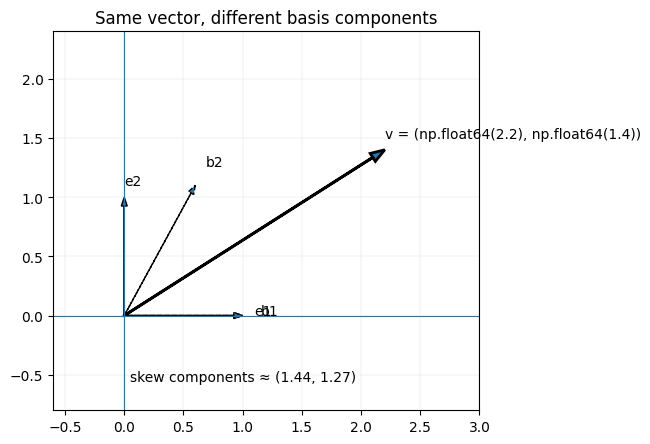

In [79]:
_ = plot_basis_change()



### Contravariant and covariant scaling

Contravariant components scale oppositely to a change of basis or unit, while covariant components such as rates scale with the dual basis.


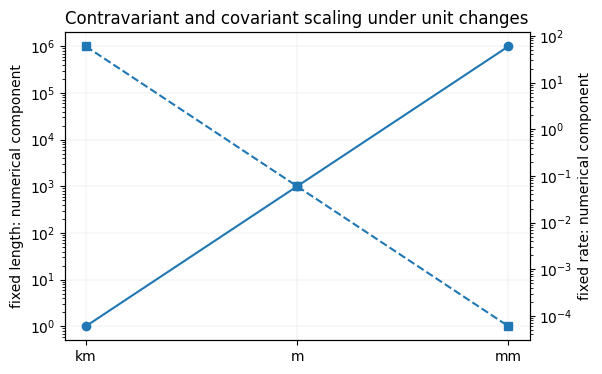

In [80]:
_ = plot_contravariant_covariant_scaling()



### Covectors as level-set counters

A covector is a linear functional. Its level sets make the pairing with a vector visible: the sign and magnitude depend on how the vector crosses the level sets.


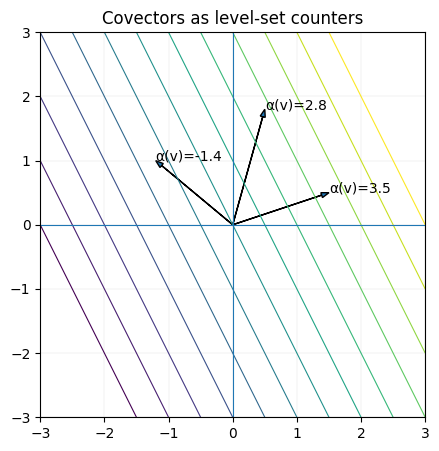

In [81]:
_ = plot_covector_level_sets()



### Dual bases and the Kronecker delta

The dual basis is characterized by $\epsilon^i(e_j)=\delta^i{}_j$. In a non-orthogonal basis, the dual covectors are not obtained by simply drawing perpendicular copies of the basis vectors.


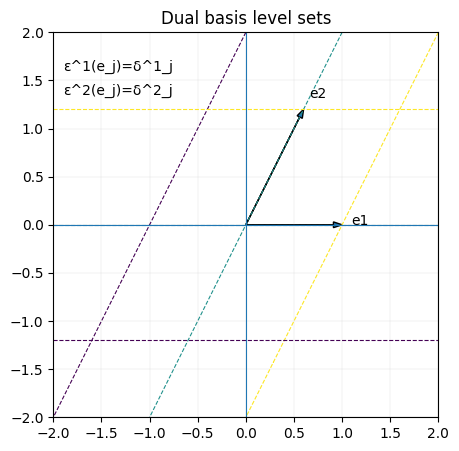

In [82]:
_ = plot_dual_basis()



### Metric unit ellipses

A metric is a measurement rule. The set $v^T g v=1$ is a circle only for the Euclidean identity metric; anisotropic metrics produce ellipses.


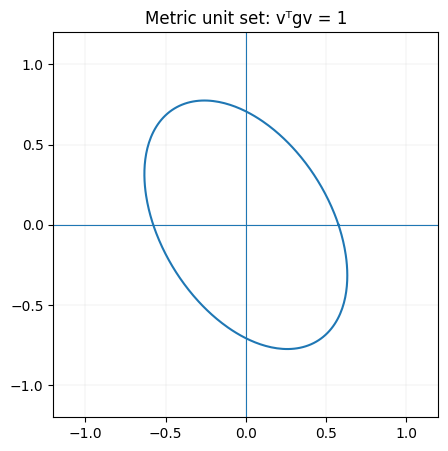

In [83]:
_ = plot_metric_unit_ellipse()



### Raising and lowering

Lowering an index with a metric converts a vector into a covector. Visually, the covector can be shown as a family of level sets associated with $v^\flat=g(v,\cdot)$.


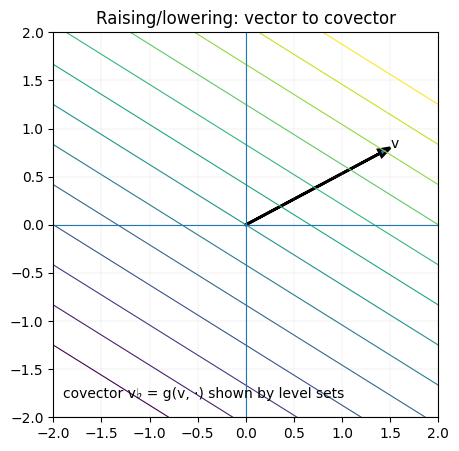

In [84]:
_ = plot_raising_lowering()



### Tensor products as outer-product heatmaps

An elementary tensor such as $v\otimes\alpha$ can be visualized as an outer product. General tensors are linear combinations of elementary tensors.


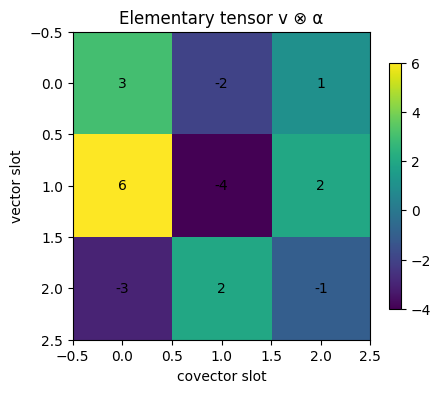

In [85]:
_ = plot_tensor_product_heatmap()



### Contraction as wiring slots

Contraction pairs one vector-like slot with one covector-like slot. Matrix multiplication and traces are familiar examples of this slot-wiring operation.


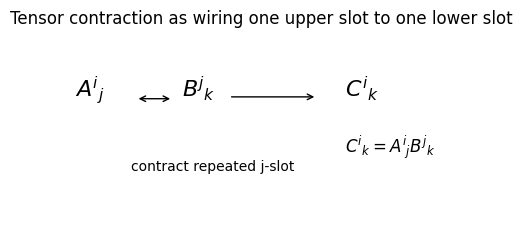

In [86]:
_ = plot_contraction_diagram()



### Vector fields and changing coordinate bases

In polar coordinates, the radial basis direction changes from point to point. Component fields must be interpreted relative to the local basis.


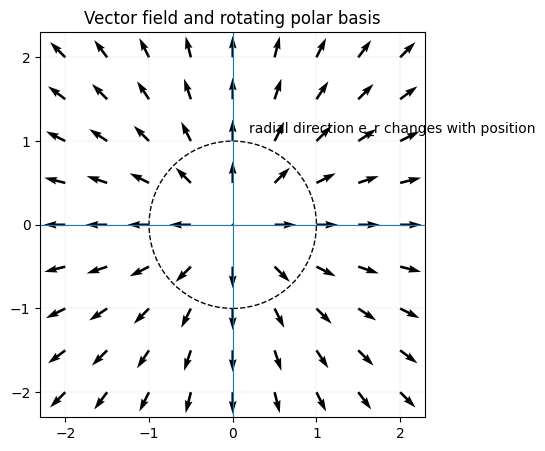

In [87]:
_ = plot_vector_field_transformation()



### Differential forms

A 1-form can be visualized by level sets; a 2-form represents oriented area such as $dx\wedge dy$.


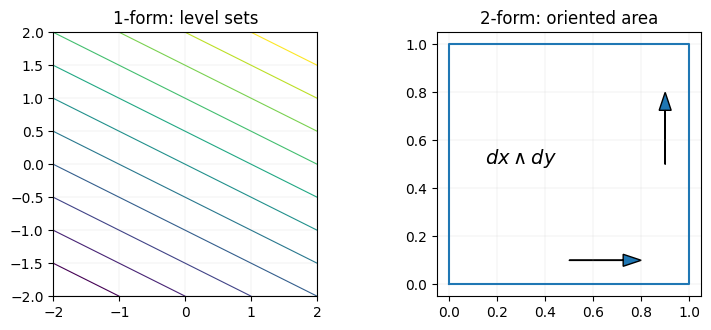

In [88]:
_ = plot_differential_form_visual()



### Pullbacks as mapped grids

A pullback moves fields and forms from a target space back to a parameter space. A mapped grid makes the chain-rule geometry visible.


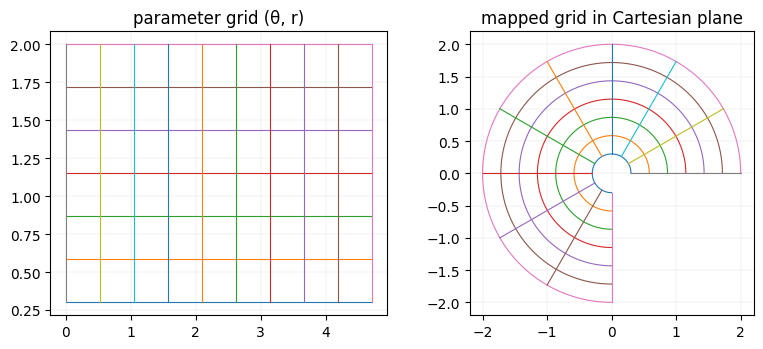

In [89]:
_ = plot_pullback_grid()



### Curvature on a sphere

Curvature can be motivated by parallel transport around a loop. On a sphere, transport around a spherical triangle can rotate a tangent vector.


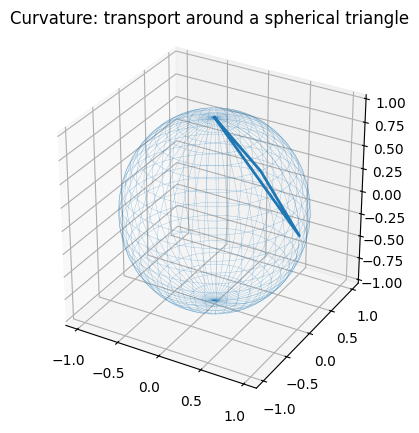

In [90]:
_ = plot_curvature_on_sphere()



### Geodesics on the sphere

Great circles are geodesics on a round sphere, while most latitude circles are not. This picture connects geodesic equations to geometry.


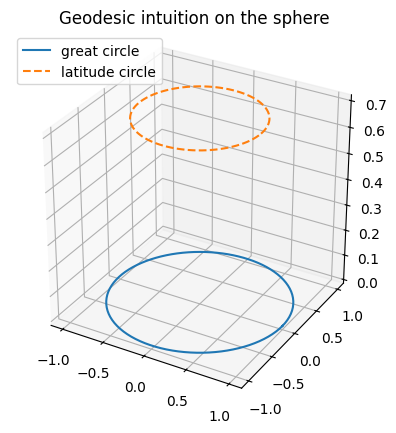

In [91]:
_ = plot_sphere_geodesic()



### Stress tensor components

The stress tensor records normal and shear forces per unit area on faces of a material element.


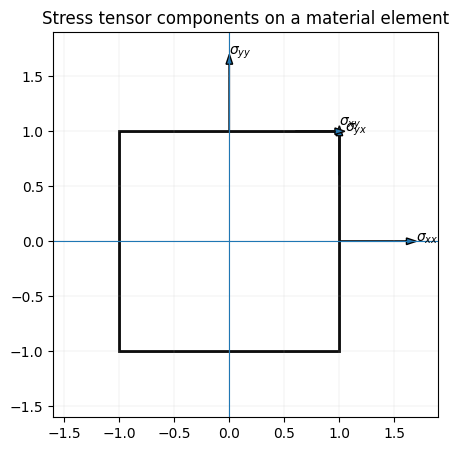

In [92]:
_ = plot_stress_element()



### Strain tensor components

The strain tensor records deformation. Normal strain stretches or compresses; shear strain changes angles.


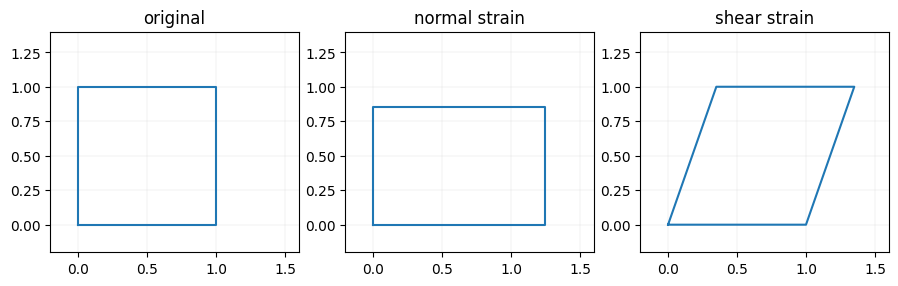

In [93]:
_ = plot_strain_deformation()



### Quadrupole density pattern

The disk density proportional to $x^2-y^2$ has positive and negative lobes, making the quadrupole moment tensor visually plausible.


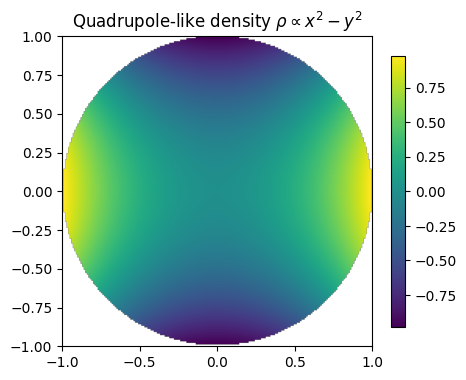

In [94]:
_ = plot_quadrupole_density()



### Geometric algebra rotor rotation

Rotor actions have the form $RvR^{-1}$. In 2D, this reduces to the familiar rotation of a vector through an angle.


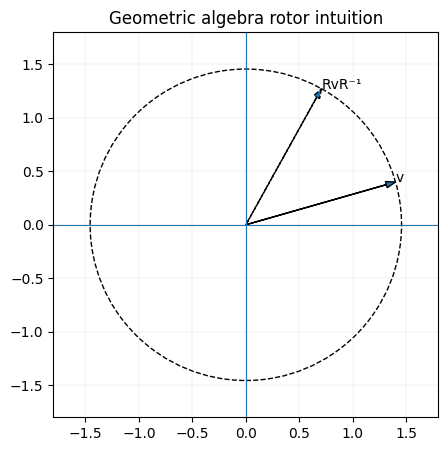

In [95]:
_ = plot_rotor_rotation()


### Canonicalization as convergence to normal form

TensorAtlas canonicalization rewrites equivalent expressions through dummy-index renaming, symmetry rules, and normal-form comparison.


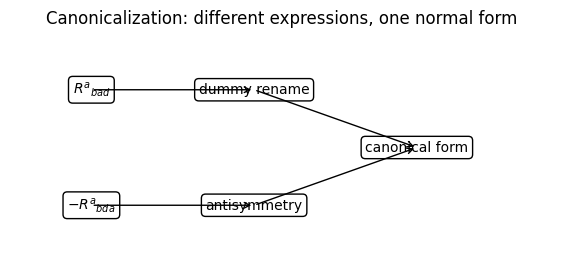

In [96]:
_ = plot_canonicalization_tree()



## Check-your-understanding prompts

These prompts mirror the tutorial's conceptual arc and are intended as quick self-checks.

1. Why is a component array not, by itself, a tensor?
2. In a non-orthogonal basis, why is the dual basis not the same as the original basis?
3. Which object is covariant: a displacement vector or a gradient of a scalar field?
4. What tensor type is a linear map from vectors to vectors?
5. What tensor type is a metric before an index is raised?
6. Which slots are removed when a tensor is contracted?
7. Why does a metric represented by a matrix still not behave like an ordinary vector-to-vector matrix?
8. In a coordinate transformation, why do vector and covector components use inverse Jacobian factors relative to each other?
